***
***
# **Counting the ~~Uncounted~~**: 
# *A GBV Visibility Index Across Kenya's 44 Counties*
***
***


**Author:** [Madlene Oloo]  
**Date:** May 1 2026  
**Tools:** Python · requests · matplotlib · openpyxl . Streamlit 

## The Problem

> Every year in Kenya, thousands of women are assaulted and never counted and yet, we are making policy decisions based on the women we did count.

- According to the Kenya Demographic and Health Survey, 15.8% of women aged 15–49 experienced physical violence in the last 12 months, and 13.0% had ever experienced sexual violence at county level.(Kenya National Bureau of Statistics [KNBS], 2023).

- The real problem isn't just violence but invisibility. As the World Bank Gender Data Portal indicates, Kenya's gender-based violence indicators have shown persistent prevalence over multiple survey cycles.(World Bank, 2024).

- This project asks one question:

> **Which counties in Kenya have the largest gap between how many
> women experience gender-based violence and how many cases are
> officially recorded?**

- The answer tells us not where violence is worst but where the system is most blind.

## The Research Approach

- This analysis follows the same logic as a research paper by triangulating across three sources of increasing specificity:

**1. The World Bank Gender Data API** establishes Kenya's national baseline. This is the globally recognized, internationally standardised picture of where Kenya sits on GBV indicators over time. It answers: what do we already know?

**2. The Kenya Demographic and Health Survey (KDHS) 2022** is the primary field evidence. Conducted by KNBS across all 47 counties, this is the most authoritative Kenya-specific dataset available. It answers: what did women report experiencing, county by county?

**3. The National Crime Research Center (2022) 2021 annual crime yearbook** is the counterargument. This is what the state recorded. It answers: what did the system actually see?

- The gap between source 2 and source 3 is the finding.

## What This Project Produces

- A **visibility score** for each county: how many women reported experiencing violence 
  for every one case that reached the police
- A **ranked bar chart** of all counties by their underreporting index
- An **Excel report** that any NGO or county government office could open, filter, and act on tomorrow

***

## *Section 1:* Kenya Gender Data from World Bank API

In [18]:
# Establishing the national baseline
# Pull data from the World Bank's Gender Data Portal
# These Gender indicators show physical violence, 
# sexual violence & attitudes toward violence.

import requests

# Create dictionary to store the Indicators & Indicators ID
indicators = {
    "Physical Violence (% of women ages 15-49)": "WB.GS.SG.VAW.1549.ZS",
    "Sexual Violence (% of women ages 15-49)": "SG.VAW.AFSX.ZS",
    "Husband is Justified to Beat Wife (% agree)": "SG.VAW.REAS.ZS"
              }

indicators.keys() 
indicators.values()
indicators.items()
indicator_name = "indicators.keys()"
indicator_id = "indicators.values()"

# Country Code: KEN
# Source: 14 (Gender Data Portal)
# Requests will start with the base_url and 
# add specific code indicator at the end.

BASE_url = "https://api.worldbank.org/v2/country/KE/indicator"

# Fetch fuction to avoid writing logic 3 times
      
def fetch_indicator(indicator_name, indicator_id):
    # Build full URL
    # Combine base_url + code + JSON format + upto 20 years of data
    url = f"{BASE_url}/{indicator_id}?format=json&per_page=20"
    
    print(f"\nFetching: {indicator_name}")
    print(f"URL: {url}")
    
    # Make the request
    response = requests.get(url) # Make request

    # Check response
    if response.status_code == 200:
        print(f"Request Successful. Status code: {response.status_code}")
    
    else:
        print(f"Request Failed. Status code: {response.status_code}")

    # Read and transform text to list 
    data = response.json() # Convert text into object
    
    if len(data) < 2 or data[1] is None:
        return []
    # Loop through years returned
    # For data found, build dict {indicator_name, year,
    # value(rounded to 2 decimal places & country name)}.
    records = []
    for entry in data[1]:
        if entry["value"] is not None:
            records.append({
                "indicator": indicator_name,
                "year": int(entry["date"]),
                "value": round(entry["value"], 2),
                "country": entry["country"]["value"]
            })
    print(f"Found {len(records)} years of data")        
    return records

# Call the function *3 
national_data = {}
for name, id in indicators.items():
    national_data[name] = fetch_indicator(name, id)
print("\nKENYA NATIONAL BASELINE — SUMMARY")
    # Sort records by newest year first
for indicator_name, records in national_data.items():
    if records:
        # Sort by year descending so the most recent appears first
        records_sorted = sorted(records, key=lambda x: x["year"], reverse=True)
        most_recent = records_sorted[0]
        print(f"\n{indicator_name}")
        print(f"  Most recent data point: {most_recent['year']}")
        print(f"  Value: {most_recent['value']}%")
        print(f"  All years available: {[r['year'] for r in records_sorted]}")
    else:
        print(f"\n{indicator_name}")
        print(f"  No data available")


Fetching: Physical Violence (% of women ages 15-49)
URL: https://api.worldbank.org/v2/country/KE/indicator/WB.GS.SG.VAW.1549.ZS?format=json&per_page=20
Request Successful. Status code: 200

Fetching: Sexual Violence (% of women ages 15-49)
URL: https://api.worldbank.org/v2/country/KE/indicator/SG.VAW.AFSX.ZS?format=json&per_page=20
Request Successful. Status code: 200
Found 3 years of data

Fetching: Husband is Justified to Beat Wife (% agree)
URL: https://api.worldbank.org/v2/country/KE/indicator/SG.VAW.REAS.ZS?format=json&per_page=20
Request Successful. Status code: 200
Found 3 years of data

KENYA NATIONAL BASELINE — SUMMARY

Physical Violence (% of women ages 15-49)
  No data available

Sexual Violence (% of women ages 15-49)
  Most recent data point: 2022
  Value: 13%
  All years available: [2022, 2014, 2009]

Husband is Justified to Beat Wife (% agree)
  Most recent data point: 2022
  Value: 32.4%
  All years available: [2022, 2014, 2009]


> When looking for the data on Physical violence:
> The World Bank API returned no results for Kenya 
> on the physical violence indicator (WB.GS.SG.1549.ZS) for 2022.

- The World Bank publishes this indicator based on national Demographic and Health Surveys. Kenya's most recent DHS was conducted in 2022, but the World Bank has not yet processed those results into their API. 
- The most recent data point available through the API is from 2014.

- This gap between when data is collected and when it becomes accessible to researchers and policymakers is itself evidence of the problem this project is investigating: the systems designed to track GBV are slow, incomplete, and often several years behind reality.

***

## *Section 2, Part 1:* Kenya Demographic and Health Survey (KDHS) 2022

> This data has been dowloaded and loaded directly from the Kenya 
> Demographic and Health Survey 2022 that feeds the national 
> data captured by WorldBank gender data.

- This is the missing data that has yet  to be updated by the 
Worldbank

In [19]:
# Physical Violence Data
# Loading KDHS 2022 data
# openpyxl reads .xlsx file

import openpyxl 
import re
# Load workbook
FILE_PATH = r"C:\Users\User\Desktop\Python-Capstone-Project\Data\kdhs_2022.xlsx"

print(f"Loading: {FILE_PATH}")

workbook = openpyxl.load_workbook(FILE_PATH, data_only=True)
worksheet = workbook["June 2023"]
matches_found = 0

# Use regex to match 
pattern = re.compile(r'violence|gbv|sexual|abuse|sexual', re.IGNORECASE)

# See all sheet names
print(f"Checking starting from row 3338...\n")

for i, row in enumerate(worksheet.iter_rows(min_row=3338, values_only=True, max_row=3731)):
    row_text = " ".join(str(cell).strip() for cell in row if cell is not None)

    if pattern.search(row_text):
        print(f"MATCH FOUND at Row {i}: {row_text}")
        matches_found += 1

    if i > 3731:
        break

if matches_found == 0:
        print("No matches found. Showing raw rows 3339-3731 for debugging:")
        for row in worksheet.iter_rows(min_row=3338, max_row=3731, values_only=True):
             print(row)
else:
     print(f"\nTotal matches found: {matches_found}")

Loading: C:\Users\User\Desktop\Python-Capstone-Project\Data\kdhs_2022.xlsx
Checking starting from row 3338...

MATCH FOUND at Row 0: 29 Experience of physical violence Percentage  of Women age15 - 49 who experienced physical violence in the last 12 months often 50-54 na
MATCH FOUND at Row 1: 29 Experience of physical violence Percentage  of Women age15 - 49 who experienced physical violence in the last 12 months often Total 15-54 na
MATCH FOUND at Row 2: 29 Experience of physical violence Percentage  of Women age15 - 49 who experienced physical violence in the last 12 months sometimes Age 15-19 10
MATCH FOUND at Row 3: 29 Experience of physical violence Percentage  of Women age15 - 49 who experienced physical violence in the last 12 months sometimes Age 20-24 12.3
MATCH FOUND at Row 4: 29 Experience of physical violence Percentage  of Women age15 - 49 who experienced physical violence in the last 12 months sometimes Age 25-29 14.4
MATCH FOUND at Row 5: 29 Experience of physical violenc

***

## *Section 2, Part 2:* Core Data Denoting Geographical Breakdown 

- The Kenya Demographic and Health Survey 2022 is the most comprehensive county-level survey of women's experiences in Kenya, conducted across all 47 counties with a sample of 16,926 women aged 15–49 (KNBS, 2023).

- The raw KDHS 2022 county crosstab stored all violence indicators 
in a single collapsed row per county. This structure reflects 
a broader problem in how GBV data is published in Kenya. 
- It is designed for human reading, not machine analysis.

- The data was cleaned and restructured into a table with three 
columns per county:
    - Physical violence prevalence (last 12 months, often or sometimes)
    - Sexual violence prevalence (last 12 months)  
    - Number of women surveyed

In [20]:
# Violence Breakdown Per County
# Physical, sexual violence and survivors by county
# Loading the cleaned KDHS Data by county
# openpyxl reads .xlsx file

import openpyxl

# Load workbook
COUNTIES_FILE_PATH = r"C:\Users\User\Desktop\Python-Capstone-Project\Data\Clean_KDHS_GBV_Data_By_County.xlsx"
# Raw string to make backlashes literal

print(f"Loading: {COUNTIES_FILE_PATH}")

# Read data only on Sheet1
wb_county = openpyxl.load_workbook(COUNTIES_FILE_PATH, data_only=True)
work_sheet = wb_county.active 

print(f"Sheet loaded: {work_sheet}")

# Read headers from 2nd row
headers = [cell.value for cell in work_sheet[2]]
print(f"Columns: {headers}")

county_data = []
# Loop through sheet row by row
for row in work_sheet.iter_rows(min_row=3, values_only=True):
    county = row[0] 
    
    # Skip Total row and empty rows
    if county is None or str(county).strip().upper() == "TOTAL":
        continue # Jump straight to next loop
    
    # Convert values to float and round to 1 decimal place
    physical_pct = round(float(row[1]), 1) if row[1] is not None else None
    sexual_pct = round(float(row[2]), 1) if row[2] is not None else None
    num_women = int(row[3]) if row[3] is not None else None # This row has whole numbers

    county_data.append({
         "county": county,
         "physical_violence_pct": physical_pct,
         "sexual_violence_pct": sexual_pct,
         "num_women": num_women
    })
    
print(f"\nCounties loaded: {len(county_data)}")

# Add num of women surveyed 
total_women = sum(c["num_women"] for c in county_data)

# Calculate weighted average
# Mirror how KDHS calculated the national figure
weighted_physical = sum(
    c["physical_violence_pct"] * c["num_women"]
    for c in county_data
) / total_women

# Calculate absolute difference to determine accuracy
print(f" Match: {"Yes" if abs(weighted_physical - 15.8) < 1 else"Check data"}")

# Use format specifier 
for county in county_data[:20]:
    print(f" {county["county"]:<20} "
          f"Physical: {county["physical_violence_pct"]}% "
          f"Sexual: {county["sexual_violence_pct"]}% "
          f"n={county["num_women"]}")

Loading: C:\Users\User\Desktop\Python-Capstone-Project\Data\Clean_KDHS_GBV_Data_By_County.xlsx
Sheet loaded: <Worksheet "Sheet1">
Columns: ['County', '%Physical_Violence_12mo_pct (29C)', '%Sexual_Violence_12mo_pct (31C)', 'Number_of_Women', None, None, None]

Counties loaded: 47
 Match: Yes
 Mombasa              Physical: 11.5% Sexual: 3.8% n=500
 Kwale                Physical: 11.3% Sexual: 3.3% n=264
 Kilifi               Physical: 8.3% Sexual: 6.5% n=491
 Tana River           Physical: 23.2% Sexual: 1.5% n=81
 Lamu                 Physical: 12.0% Sexual: 6.3% n=51
 Taita/Taveta         Physical: 7.4% Sexual: 3.0% n=110
 Garissa              Physical: 12.8% Sexual: 3.5% n=148
 Wajir                Physical: 5.5% Sexual: 1.0% n=84
 Mandera              Physical: 3.3% Sexual: 0.8% n=104
 Marsabit             Physical: 14.2% Sexual: 1.0% n=68
 Isiolo               Physical: 29.3% Sexual: 5.3% n=69
 Meru                 Physical: 15.1% Sexual: 8.2% n=547
 Tharaka-Nithi        Physical: 1

***

## *Section 3:* NCRC 2021 Annual Crime Yearbook - Table 1.3

- The 2021 NCRC Annual Crime Yearbook contains county-level GBV prevalence data from community crime perception surveys across all 47 counties. 

- This represents the officially recorded/perceived 
GBV rate at county level i.e the reported side of our gap ratio.

    - Note: Kwale, Lamu, and Garissa returned NULL in the source table. These counties are excluded from the gap ratio calculation. This exclusion is documented as a limitation of the analysis. 
- However, this data exists only as PDF tables. There is no machine-readable, downloadable 
dataset available. This is not a technical oversight. It is a structural one.

> When key GBV crime data requires manual extraction 
> to be usable for analysis, does that signal that 
> this data was not designed to be analysed but to
> be filed?

- The extraction performed here is itself evidence of the barrier between data that exists and data that is accessible.

In [21]:
# Load Police-Side GBV Data
# Select active sheet

import openpyxl
 
File_PATH = r"C:\Users\User\Desktop\Python-Capstone-Project\Data\Clean_Police_GBV_Data_By_County.xlsx"

Wb = openpyxl.load_workbook(File_PATH, data_only = True)
sheet = Wb.active 

print(f"Sheet: {sheet.title}")

police_data = {} # Create dict

# Iterate from 3rd row
for row in sheet.iter_rows(min_row = 3, values_only = True):
    county = row[0]
    pct = row[1]

    # To skip NULLs, Unnecessary and Empty rows
    if county is None and pct is None:
        continue
    # Clean the data
    if str(county).strip().lower() in ["county", "national percentage", ""]:
        continue
    if str(pct).strip().upper() in ["NULL", ""]:
        print(f"{county}: NULL - excluded from analysis")
        continue # Only skip null records
    
    try:
        police_data[str(county)] = round(float(pct), 1)
    except ValueError:
        print(f"{county}: could not parse value '{pct}'")
        continue

print(f"\nCounties loaded: {len(police_data)}")
print(f"\nPreview:")
for county, pct in list(police_data.items())[:20]:
    print(f"{county: <20} {pct}%")

Sheet: Sheet1
Kwale: NULL - excluded from analysis
Lamu: NULL - excluded from analysis
Garissa: NULL - excluded from analysis

Counties loaded: 44

Preview:
Mombasa              4.3%
Kilifi               3.4%
Tana River           3.2%
Taita/Taveta         4.8%
Wajir                2.9%
Mandera              0.9%
Marsabit             12.2%
Isiolo               16.7%
Meru                 10.6%
Tharaka-Nithi        23.8%
Embu                 33.8%
Kitui                1.0%
Machakos             4.3%
Makueni              4.9%
Nyandarua            1.7%
Nyeri                8.6%
Kirinyaga            2.9%
Murang'a             9.7%
Kiambu               5.7%
Turkana              22.3%


In [22]:
print(list(police_data.keys()))

['Mombasa', 'Kilifi', 'Tana River', 'Taita/Taveta', 'Wajir', 'Mandera', 'Marsabit', 'Isiolo', 'Meru', 'Tharaka-Nithi', 'Embu', 'Kitui', 'Machakos', 'Makueni', 'Nyandarua', 'Nyeri', 'Kirinyaga', "Murang'a", 'Kiambu', 'Turkana', 'West Pokot', 'Samburu', 'Trans Nzoia', 'Uasin Gishu', 'Elgeyo/Marakwet', 'Nandi', 'Baringo', 'Laikipia', 'Nakuru', 'Narok', 'Kajiado', 'Kericho', 'Bomet', 'Kakamega', 'Vihiga', 'Bungoma', 'Busia', 'Siaya', 'Kisumu', 'Homa Bay', 'Migori', 'Kisii', 'Nyamira', 'Nairobi']


***

## *Section 4:* The Visibility Score Calculation

- This is the core of the analysis.

- For each county we calculate a simple ratio:

> **Visibility Score = KDHS Physical Violence % / NCRC Reported GBV %**

    - A low visibility score means the system sees very little of what is actually happening. A high visibility score means more of the real picture is reaching official attention.

In [23]:
# VISIBILTY RATIO CALCULATION
# For each county in the KDHS & NCRC data: 
# visibility_score = kdhs_physical_violence_pct / police_gbv_pct

# High score == High undereporting
# Low score == Relatively better reporting

# Convert KDHS data to dict and build lookup
kdhs_lookup = {
    entry["county"].strip(): entry["physical_violence_pct"]
    for entry in county_data
}

print(f"KDHS counties available: {len(kdhs_lookup)}")
print(f"Police counties available: {len(police_data)}")

# Calculate visibility score for matched counties where 
# both datasets have a value.
# Missing values are skipped

visibility_scores = []
skipped = []

# Loop to find county in KDHS data
for county, police_pct in police_data.items():
    kdhs_pct = kdhs_lookup.get(county)

    if kdhs_pct is None:
        skipped.append(county)
        continue

    # If report was 0%
    if police_pct == 0:
        skipped.append(f"{county} (police pct = 0)")
        continue
    visibility = round(kdhs_pct / police_pct, 2)

    visibility_scores.append({
        "county": county,
        "kdhs_physical_pct": kdhs_pct,
        "police_gbv_pct": police_pct,
        "visibility_score": visibility
    })

# Sort by highest gap ratio
visibility_scores_sorted = sorted(visibility_scores, key=lambda x: x["visibility_score"], reverse=True)

# Print table
print(f"\nCounties with visibility score calculated: {len(visibility_scores_sorted)}")
print(f"Counties skipped: {len(skipped)} - {skipped}")

print(f"\n{'=' * 65}")
print(f"{'RANK':<6} {'COUNTY':<20} {'KDHS %':<12} {'POLICE %':<12} {'VISIBILITY SCORE'}")
print(f"{'=' * 65}")

for i, row in enumerate(visibility_scores_sorted, start=1):
    print(
        f"{i:<6}"
        f"{row['county']:<20}"
        f"{row['kdhs_physical_pct']:<12}"
        f"{row['police_gbv_pct']:<12}"
        f"{row['visibility_score']}"
    )

KDHS counties available: 47
Police counties available: 44

Counties with visibility score calculated: 44
Counties skipped: 0 - []

RANK   COUNTY               KDHS %       POLICE %     VISIBILITY SCORE
1     Tana River          23.2        3.2         7.25
2     Kisumu              26.0        3.9         6.67
3     Bungoma             29.4        5.8         5.07
4     Kitui               4.7         1.0         4.7
5     Kirinyaga           12.5        2.9         4.31
6     Vihiga              17.1        4.1         4.17
7     Baringo             19.6        5.2         3.77
8     Mandera             3.3         0.9         3.67
9     Laikipia            11.7        3.3         3.55
10    Nandi               15.0        4.3         3.49
11    Kakamega            19.1        5.8         3.29
12    Kiambu              17.9        5.7         3.14
13    Nyandarua           5.0         1.7         2.94
14    West Pokot          19.1        6.8         2.81
15    Nairobi             13.

In [ ]:
import json

# Save list to be used on Streamlist
clean_output = [
    {
        "county": r["county"],
        "kdhs_physical_pct": r["kdhs_physical_pct"],
        "police_gbv_pct": r["police_gbv_pct"],
        "visibility_score": r["visibility_score"]
    }
    for r in visibility_scores_sorted
]

with open(r"C:\Users\User\Desktop\Python-Capstone-Project\visibility_scores.json", "w") as f:
    json.dump(clean_output, f, indent=2)

# Confirm the list is showing the values 
print(f"Saved {len(clean_output)} counties to visibility_scores.json")
print(f"Preview: {clean_output[0]}")

Saved 44 counties to visibility_scores.json
Preview: {'county': 'Tana River', 'kdhs_physical_pct': 23.2, 'police_gbv_pct': 3.2, 'visibility_score': 7.25}


## *THE HEADLINE FINDINGS*

In [25]:
# THE HEADLINE FINDINGS

Most_underreported = visibility_scores_sorted[0]
Least_underreported = visibility_scores_sorted[-1]

print(f"""
      KEY FINDINGS\n
      Most undereported county: {Most_underreported['county']}
      KDHS prevalence: {Most_underreported['kdhs_physical_pct']}%
      Police reported: {Most_underreported['police_gbv_pct']}%
      Visibility Score: {Most_underreported['visibility_score']}
      
      Least underreported county: {Least_underreported['county']}
      KDHS prevalence: {Least_underreported['kdhs_physical_pct']}%
      Police reported: {Least_underreported['police_gbv_pct']}%
      Visibility Score: {Least_underreported['visibility_score']}
      """)


      KEY FINDINGS

      Most undereported county: Tana River
      KDHS prevalence: 23.2%
      Police reported: 3.2%
      Visibility Score: 7.25

      Least underreported county: Bomet
      KDHS prevalence: 10.7%
      Police reported: 30.9%
      Visibility Score: 0.35
      


## *Section 5:* Visualization (Visibility Score Bar Chart)

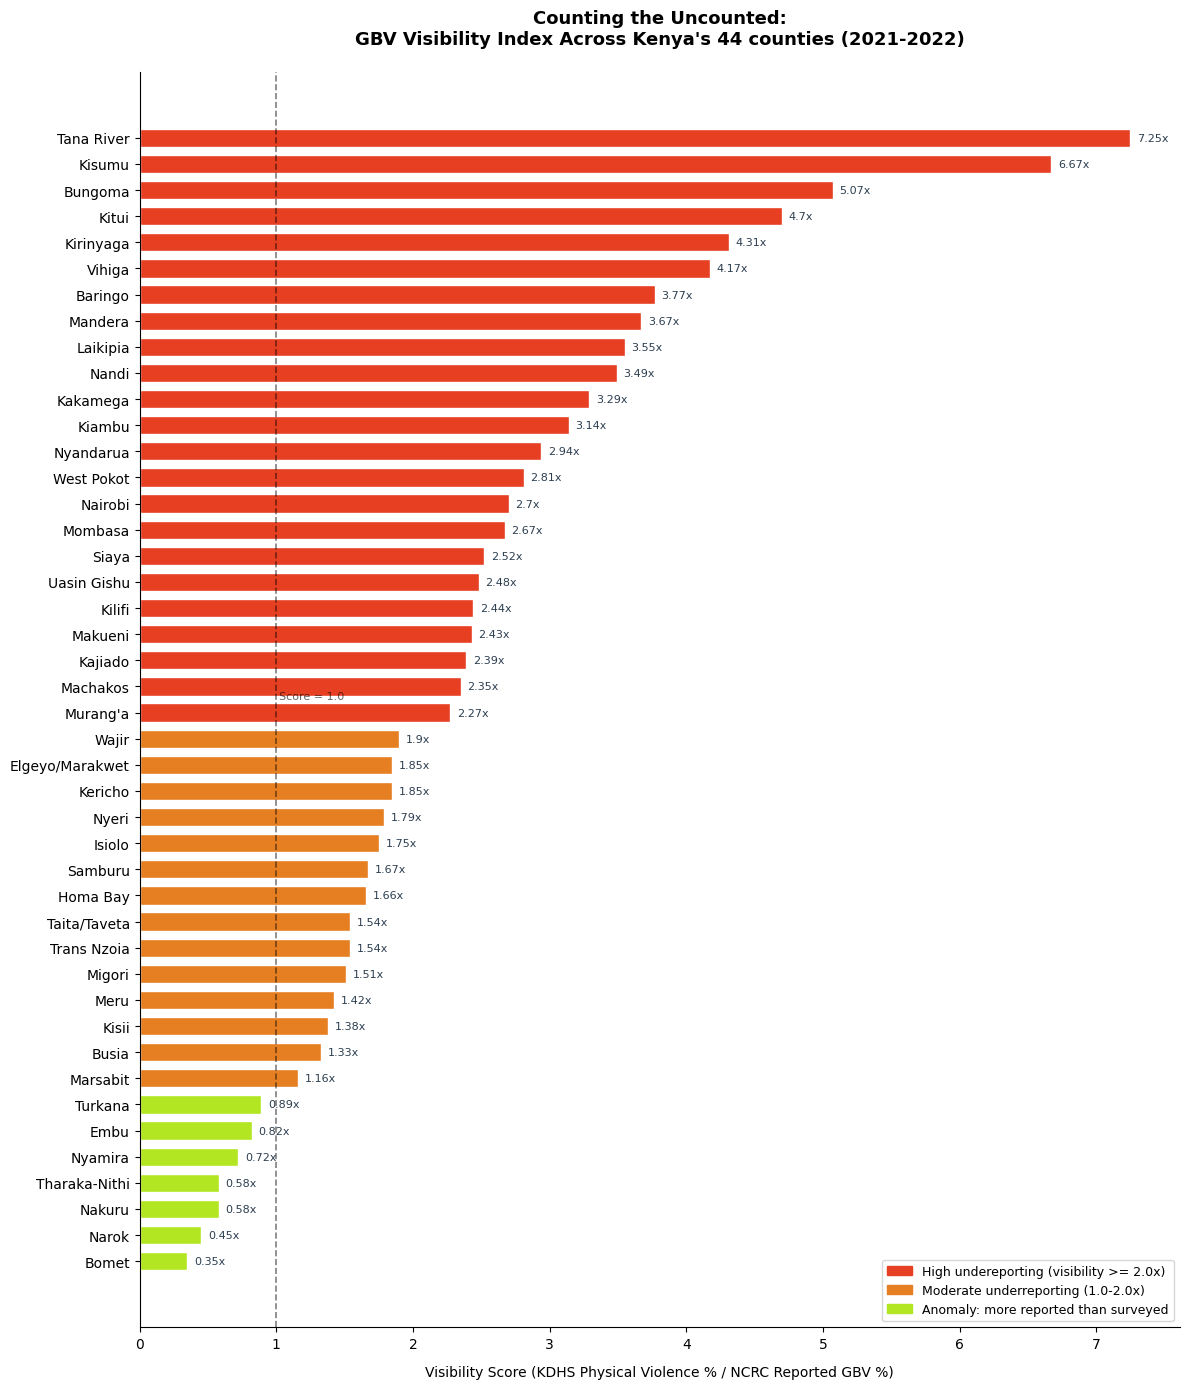


Chart saved to: C:\Users\User\Desktop\Python-Capstone-Project\Outputs\gbv_visibility_score_chart.png


In [26]:
# Plot all 44 counties ranked by gap ratio

from matplotlib import pyplot as plt
from matplotlib import patches as mpatches

# Prepare data to plot
counties = [row["county"] for row in visibility_scores_sorted]
visibility = [row["visibility_score"] for row in visibility_scores_sorted]

# Colors:
# Make red high underreporting (visibility > 2.0) 
# Make orange moderate underreporting (visibility 1.0 - 2.0)
# Make yellow anomaly reporting where reports outdo women surveyed

colors = []
for v in visibility:
    if v >= 2.0:
        colors.append("#E63F22")
    elif v >= 1.0:
        colors.append("#E67E22")
    else:
        colors.append("#B2E622")

# Build the chart
fig, ax = plt.subplots(figsize=(12, 14))

bars = ax.barh(
    counties, 
    visibility, 
    color=colors, 
    edgecolor="white", 
    height=0.7)

# Add reference lines for high underreporting, moderate underreporting.

ax.axvline(x=1.0, color="black", linewidth=1.2, linestyle="--", alpha=0.5)
ax.text(
    1.02, 0.5, 
    "Score = 1.0",
    transform=ax.get_xaxis_transform(),
    fontsize=8, 
    alpha=0.6)

# Add value labels on bars
for bar, ratio in zip(bars, visibility):
    ax.text(
        bar.get_width() + 0.05, # end of bar
        bar.get_y() + bar.get_height() / 2, # center vertically
        f"{ratio}x", # this value only
        va="center",
        ha="left",
        fontsize=8,
        color="#2C3E50"
    )

# Add titles & labels

ax.set_xlabel("Visibility Score (KDHS Physical Violence % / NCRC Reported GBV %)",
              fontsize=10, labelpad=10)
ax.set_title(
    "Counting the Uncounted:\nGBV Visibility Index Across Kenya's 44 counties (2021-2022)",
    fontsize=13, fontweight="bold", pad=20
)

# Invert y-axis to reflect highest visibility scores at the top
ax.invert_yaxis()

# Legend
red_patch = mpatches.Patch(color="#E63F22", label="High undereporting (visibility >= 2.0x)")
orange_patch = mpatches.Patch(color="#E67E22", label="Moderate underreporting (1.0-2.0x)")
yellow_patch = mpatches.Patch(color="#B2E622", label="Anomaly: more reported than surveyed")
ax.legend(handles=[red_patch, orange_patch, yellow_patch],
          loc="lower right", fontsize=9)

# Clean up chart frame
ax.spines["top"]. set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save chart
Output_PATH = r"C:\Users\User\Desktop\Python-Capstone-Project\Outputs\gbv_visibility_score_chart.png"
plt.savefig(Output_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nChart saved to: {Output_PATH}")

## *Conclusion:* Insights & Recommendations

## References

Kenya National Bureau of Statistics (KNBS).(2023). *Kenya Demographic 
    and Health Survey 2022: County crosstab* [Data set]. African Development 
    
Data Hub. https://ckan.africadatahub.org/dataset/kenya-demographic-and-health-survey-2022

National Crime Research Centre. (2022). *2021 annual crime yearbook*. 
    Government of Kenya. https://www.crimeresearch.go.ke/wp-content/uploads/2022/07/2021-ANNUAL-CRIME-YEAR-BOOK.pdf

World Bank. (2024). *Gender data portal: Kenya* [Data set]. 
    World Bank Group. https://genderdata.worldbank.org/en/economies/kenya

*Data collection, cleaning, analysis and visualisation conducted using 
Python 3. Libraries used: requests, BeautifulSoup4, openpyxl, 
matplotlib, Streamlit. All data sources are publicly accessible.*